# TFM — Modelos comparativos por horizonte temporal

Este notebook replica el pipeline de modelado de `trabajo_final_models.ipynb` aplicándolo a **cuatro escenarios temporales** y a un **experimento adicional** que contrasta `train_test_split` aleatorio frente a `TimeSeriesSplit` (validación temporal walk-forward).

## Escenarios
- **Escenario A — Histórico completo** (sin filtro temporal)
- **Escenario B — 30 años** (`year >= max_year - 30`)
- **Escenario C — 20 años** (`year >= max_year - 20`)
- **Escenario D — 10 años** (`year >= max_year - 10`)

## Modelos
- Regresión logística multinomial (con StandardScaler en pipeline)
- Random Forest
- HistGradientBoosting

## Métricas
Accuracy, F1 macro, F1 weighted, AUC macro multiclase, KS por clase, matriz de confusión, importancia de variables (RF) y ROC.

> Archivo de trabajo `processed_matches.csv` 


## 1. Imports y configuración

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.model_selection import TimeSeriesSplit, train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report,
    confusion_matrix, roc_auc_score, roc_curve
)

import warnings
warnings.filterwarnings("ignore")

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 2000)
SEED = 42
N_SPLITS = 5


## 2. Carga del dataset y target

In [2]:
df_full = pd.read_csv('processed_matches.csv')
print('Filas:', df_full.shape[0], 'Columnas:', df_full.shape[1])
print('Año mínimo:', df_full['year'].min(), 'Año máximo:', df_full['year'].max())
df_full.head()


Filas: 49971 Columnas: 209
Año mínimo: 1872 Año máximo: 2025


,home_rank_position,home_rank_points,away_rank_position,away_rank_points,rank_points_diff,year,neutral,has_shootout,tourn_AFC Asian Cup,tourn_AFC Asian Cup qualification,tourn_AFC Challenge Cup,tourn_AFC Challenge Cup qualification,tourn_AFF Championship,tourn_AFF Championship qualification,tourn_ASEAN Championship,tourn_ASEAN Championship qualification,tourn_African Cup of Nations,tourn_African Cup of Nations qualification,tourn_African Friendship Games,tourn_Afro-Asian Games,tourn_Al Ain International Cup,tourn_All-African Games,tourn_Amílcar Cabral Cup,tourn_Arab Cup,tourn_Arab Cup qualification,tourn_Asian Games,tourn_Atlantic Cup,tourn_Atlantic Heritage Cup,tourn_Balkan Cup,tourn_Baltic Cup,tourn_Beijing International Friendship Tournament,tourn_Benedikt Fontana Cup,tourn_Bolivarian Games,tourn_Brazil Independence Cup,tourn_British Home Championship,tourn_CAFA Nations Cup,tourn_CCCF Championship,tourn_CECAFA Cup,tourn_CFU Caribbean Cup,tourn_CFU Caribbean Cup qualification,tourn_CONCACAF Championship,tourn_CONCACAF Championship qualification,tourn_CONCACAF Nations League,tourn_CONCACAF Nations League qualification,tourn_CONCACAF Series,tourn_CONIFA Africa Football Cup,tourn_CONIFA Asia Cup,tourn_CONIFA European Football Cup,tourn_CONIFA South America Football Cup,tourn_CONIFA World Football Cup,tourn_CONIFA World Football Cup qualification,tourn_CONMEBOL–UEFA Cup of Champions,tourn_COSAFA Cup,tourn_COSAFA Cup qualification,tourn_Canadian Shield,tourn_Central American and Caribbean Games,tourn_Central European International Cup,tourn_ConIFA Challenger Cup,tourn_Confederations Cup,tourn_Copa América,tourn_Copa América qualification,tourn_Copa Artigas,tourn_Copa Bernardo O'Higgins,tourn_Copa Carlos Dittborn,tourn_Copa Chevallier Boutell,tourn_Copa Confraternidad,tourn_Copa Félix Bogado,tourn_Copa Juan Pinto Durán,tourn_Copa Lipton,tourn_Copa Newton,tourn_Copa Oswaldo Cruz,tourn_Copa Paz del Chaco,tourn_Copa Premio Honor Argentino,tourn_Copa Premio Honor Uruguayo,tourn_Copa Ramón Castilla,tourn_Copa Rio Branco,tourn_Copa Roca,tourn_Copa del Pacífico,tourn_Corsica Cup,tourn_Coupe de l'Outre-Mer,tourn_Cup of Ancient Civilizations,tourn_Cyprus International Tournament,tourn_Dakar Tournament,tourn_Dragon Cup,tourn_Dunhill Cup,tourn_Dynasty Cup,tourn_EAFF Championship,tourn_EAFF Championship qualification,tourn_ELF Cup,tourn_East Asian Games,tourn_FIFA 75th Anniversary Cup,tourn_FIFA Series,tourn_FIFA World Cup,tourn_FIFA World Cup qualification,tourn_FIFI Wild Cup,tourn_Far Eastern Championship Games,tourn_Four Nations Tournament,tourn_Four Nations' Cup,tourn_Friendlies,tourn_Friendly,tourn_GaNEFo,tourn_Gold Cup,tourn_Gold Cup qualification,tourn_Great Wall Cup,tourn_Guangzhou International Friendship Tournament,tourn_Gulf Cup,tourn_Hungary Heritage Cup,tourn_Indian Ocean Island Games,tourn_Indonesia Tournament,tourn_Inter Games,tourn_Inter-Allied Games,tourn_Intercontinental Cup,tourn_Island Games,tourn_Joe Robbie Cup,tourn_Jordan International Tournament,tourn_King Hassan II Tournament,tourn_King's Cup,tourn_Kirin Challenge Cup,tourn_Kirin Cup,tourn_Korea Cup,tourn_Kuneitra Cup,tourn_Lunar New Year Cup,tourn_MSG Prime Minister's Cup,tourn_Mahinda Rajapaksa Cup,tourn_Malta International Tournament,tourn_Mapinduzi Cup,tourn_Marianas Cup,tourn_Marlboro Cup,tourn_Matthews Cup,tourn_Mauritius Four Nations Cup,tourn_Merdeka Tournament,tourn_Merlion Cup,tourn_Miami Cup,tourn_Millennium Cup,tourn_Mundialito,tourn_Muratti Vase,tourn_NAFC Championship,tourn_NAFU Championship,tourn_Nations Cup,tourn_Navruz Cup,tourn_Nehru Cup,tourn_Niamh Challenge Cup,tourn_Nile Basin Tournament,tourn_Nordic Championship,tourn_OSN Cup,tourn_Oceania Nations Cup,tourn_Oceania Nations Cup qualification,tourn_Olympic Games,tourn_Open International Championship,tourn_Outrigger Challenge Cup,tourn_Pacific Games,tourn_Pacific Mini Games,tourn_Palestine Cup,tourn_Pan American Championship,tourn_Peace Cup,tourn_Phillip Seaga Cup,tourn_Prime Minister's Cup,tourn_Re

In [3]:
# Ingeniería de características (idéntica al notebook original)
def feature_engineering(df):
    df = df.copy()
    df['rank_position_diff'] = df['away_rank_position'] - df['home_rank_position']
    df['rank_points_diff']   = df['home_rank_points']   - df['away_rank_points']
    df['rank_points_sum']    = df['home_rank_points']   + df['away_rank_points']
    df['rank_points_ratio']  = df['home_rank_points'] / (df['away_rank_points'] + 1)
    df['abs_rank_points_diff'] = df['rank_points_diff'].abs()
    df['log_home_rank_points'] = np.log1p(df['home_rank_points'])
    df['log_away_rank_points'] = np.log1p(df['away_rank_points'])
    df['inv_home_rank_position'] = 1 / (df['home_rank_position'] + 1)
    df['inv_away_rank_position'] = 1 / (df['away_rank_position'] + 1)
    df['is_close_match'] = (df['abs_rank_points_diff'] < 50).astype(int)

    df['target'] = np.select(
        [df['home_score'] > df['away_score'],
         df['home_score'] == df['away_score'],
         df['home_score'] < df['away_score']],
        [2, 1, 0]
    )
    df['has_shootout'] = df['has_shootout'].astype(int)
    df['neutral']      = df['neutral'].fillna(0).astype(int)

    tournament_features = [c for c in df.columns if c.startswith('tourn_')]
    for c in tournament_features:
        df[c] = (df[c] > 0).astype(int)
    return df, tournament_features

df_full, tournament_features = feature_engineering(df_full)
print('Distribución target:')
print(df_full['target'].value_counts(normalize=True).round(3))


Distribución target:
target
2    0.490
0    0.283
1    0.227
Name: proportion, dtype: float64


In [4]:
rank_features = [
    'home_rank_position','home_rank_points',
    'away_rank_position','away_rank_points',
    'rank_points_diff'
]
engineered_features = [
    'rank_position_diff','rank_points_sum','rank_points_ratio','abs_rank_points_diff',
    'log_home_rank_points','log_away_rank_points',
    'inv_home_rank_position','inv_away_rank_position','is_close_match'
]
other_features = ['year','neutral','has_shootout']
features = rank_features + engineered_features + other_features + tournament_features
target = 'target'
print('Total de features:', len(features))


Total de features: 211


## 3. Función de evaluación walk-forward (TimeSeriesSplit)

In [5]:
def evaluate_model_tscv(model, X, y, n_splits=N_SPLITS, scale=False):
    """Walk-forward CV. Devuelve métricas consolidadas y predicciones."""
    tscv = TimeSeriesSplit(n_splits=n_splits)
    all_y_test, all_y_pred, all_y_proba = [], [], []
    fold_acc = []
    fold_imp = []

    for fold, (tr, te) in enumerate(tscv.split(X), 1):
        X_tr, X_te = X[tr], X[te]
        y_tr, y_te = y[tr], y[te]

        if scale:
            sc = StandardScaler()
            X_tr_s = sc.fit_transform(X_tr)
            X_te_s = sc.transform(X_te)
            model.fit(X_tr_s, y_tr)
            y_pred = model.predict(X_te_s)
            y_proba = model.predict_proba(X_te_s)
        else:
            model.fit(X_tr, y_tr)
            y_pred = model.predict(X_te)
            y_proba = model.predict_proba(X_te)

        all_y_test.extend(y_te); all_y_pred.extend(y_pred); all_y_proba.append(y_proba)
        fold_acc.append(accuracy_score(y_te, y_pred))
        if hasattr(model, 'feature_importances_'):
            fold_imp.append(model.feature_importances_.copy())

    y_test  = np.array(all_y_test)
    y_pred  = np.array(all_y_pred)
    y_proba = np.vstack(all_y_proba)

    classes = np.unique(y_test)
    y_bin = label_binarize(y_test, classes=classes)

    metrics = {
        'accuracy':     accuracy_score(y_test, y_pred),
        'f1_macro':     f1_score(y_test, y_pred, average='macro'),
        'f1_weighted':  f1_score(y_test, y_pred, average='weighted'),
        'auc_macro':    roc_auc_score(y_bin, y_proba, average='macro', multi_class='ovr'),
        'auc_weighted': roc_auc_score(y_bin, y_proba, average='weighted', multi_class='ovr'),
        'fold_acc':     fold_acc,
        'fold_acc_std': float(np.std(fold_acc)),
    }
    # KS por clase
    ks_by_class = {}
    for i, cl in enumerate(classes):
        fpr, tpr, _ = roc_curve(y_bin[:, i], y_proba[:, i])
        ks_by_class[int(cl)] = float(np.max(tpr - fpr))
    metrics['ks_by_class'] = ks_by_class

    if fold_imp:
        metrics['feature_importance_mean'] = np.mean(fold_imp, axis=0)
    return metrics, y_test, y_pred, y_proba


## 4. Definición de los 4 escenarios

In [6]:
max_year = df_full['year'].max()
scenarios = {
    'A_full':     ('Histórico completo', None),
    'B_30_anios': ('Últimos 30 años', max_year - 30),
    'C_20_anios': ('Últimos 20 años', max_year - 20),
    'D_10_anios': ('Últimos 10 años', max_year - 10),
}

def get_scenario_df(name):
    label, y_min = scenarios[name]
    if y_min is None:
        out = df_full.copy()
    else:
        out = df_full[df_full['year'] >= y_min].copy()
    out = out.sort_values('year').reset_index(drop=True)
    return label, out

for name in scenarios:
    label, sub = get_scenario_df(name)
    print(f'{name:12s} | {label:25s} | filas={len(sub):>6d}')


A_full       | Histórico completo        | filas= 49971
B_30_anios   | Últimos 30 años           | filas= 29999
C_20_anios   | Últimos 20 años           | filas= 21240
D_10_anios   | Últimos 10 años           | filas= 11853


## 5. Modelos a evaluar

In [7]:
def get_models():
    return {
        'LogisticRegression': (LogisticRegression(solver='lbfgs', max_iter=1000,
                                                  multi_class='multinomial', random_state=SEED), True),
        'RandomForest':       (RandomForestClassifier(n_estimators=200, random_state=SEED, n_jobs=-1), False),
        'HistGradientBoosting': (HistGradientBoostingClassifier(max_iter=200, learning_rate=0.1,
                                                               max_depth=6, random_state=SEED), False),
    }


## 6. Bucle: entrenar y evaluar todos los escenarios x todos los modelos

In [8]:
results = []  # filas: scenario, model, métricas
detailed = {}  # { (scenario, model): {y_test, y_pred, y_proba, metrics} }

for sc_name in scenarios:
    label, sub = get_scenario_df(sc_name)
    X = sub[features].values
    y = sub[target].values
    print(f'\n=== Escenario {sc_name} ({label}, n={len(sub)}) ===')

    for mod_name, (model, scale) in get_models().items():
        m, yt, yp, yproba = evaluate_model_tscv(model, X, y, scale=scale)
        print(f'  {mod_name:22s} | acc={m["accuracy"]:.4f} | f1m={m["f1_macro"]:.4f} | aucM={m["auc_macro"]:.4f}')
        row = {'scenario': sc_name, 'label': label, 'model': mod_name,
               'n': len(sub), 'accuracy': m['accuracy'], 'f1_macro': m['f1_macro'],
               'f1_weighted': m['f1_weighted'], 'auc_macro': m['auc_macro'],
               'auc_weighted': m['auc_weighted'], 'fold_acc_std': m['fold_acc_std']}
        for cl, ks in m['ks_by_class'].items():
            row[f'ks_{cl}'] = ks
        results.append(row)
        detailed[(sc_name, mod_name)] = {'y_test': yt, 'y_pred': yp, 'y_proba': yproba, 'metrics': m}

results_df = pd.DataFrame(results)
results_df.round(4)



=== Escenario A_full (Histórico completo, n=49971) ===
  LogisticRegression     | acc=0.5566 | f1m=0.4173 | aucM=0.6858
  RandomForest           | acc=0.5220 | f1m=0.4555 | aucM=0.6571
  HistGradientBoosting   | acc=0.5585 | f1m=0.4575 | aucM=0.6889

=== Escenario B_30_anios (Últimos 30 años, n=29999) ===
  LogisticRegression     | acc=0.5800 | f1m=0.4563 | aucM=0.7113
  RandomForest           | acc=0.5387 | f1m=0.4746 | aucM=0.6827
  HistGradientBoosting   | acc=0.5866 | f1m=0.4788 | aucM=0.7176

=== Escenario C_20_anios (Últimos 20 años, n=21240) ===
  LogisticRegression     | acc=0.5880 | f1m=0.4622 | aucM=0.7177
  RandomForest           | acc=0.5443 | f1m=0.4806 | aucM=0.6905
  HistGradientBoosting   | acc=0.5784 | f1m=0.4823 | aucM=0.7155

=== Escenario D_10_anios (Últimos 10 años, n=11853) ===
  LogisticRegression     | acc=0.5924 | f1m=0.4867 | aucM=0.7252
  RandomForest           | acc=0.5582 | f1m=0.4949 | aucM=0.7040
  HistGradientBoosting   | acc=0.5567 | f1m=0.4986 | aucM=

,scenario,label,model,n,accuracy,f1_macro,f1_weighted,auc_macro,auc_weighted,fold_acc_std,ks_0,ks_1,ks_2
0,A_full,Histórico completo,LogisticRegression,49971,0.5566,0.4173,0.4854,0.6858,0.6966,0.0227,0.3364,0.1420,0.3197
1,A_full,Histórico completo,RandomForest,49971,0.5220,0.4555,0.5046,0.6571,0.6689,0.0211,0.3039,0.0929,0.2804
2,A_full,Histórico completo,HistGradientBoosting,49971,0.5585,0.4575,0.5165,0.6889,0.7015,0.0412,0.3518,0.1291,0.3267
3,B_30_anios,Últimos 30 años,LogisticRegression,29999,0.5800,0.4563,0.5214,0.7113,0.7239,0.0187,0.3826,0.1760,0.3704
4,B_30_anios,Últimos 30 años,RandomForest,29999,0.5387,0.4746,0.5226,0.6827,0.6962,0.0114,0.3491,0.1213,0.3261
5,B_30_anios,Últimos 30 años,HistGradientBoosting,29999,0.5866,0.4788,0.5391,0.7176,0.7311,0.0212,0.3974,0.1722,0.3743
6,C_20_anios,Últimos 20 años,LogisticRegression,21240,0.5880,0.4622,0.5282,0.7177,0.7313,0.0182,0.4002,0.1833,0.3842
7,C_20_anios,Últimos 20 años,RandomForest,21240,0.5443,0.4806,0.5284,0.6905,0.7036,0.0169,0.3569,0.1350,0.3324
8,C_20_anios,Últimos 20 años,HistGradientBoosting,21240,0.5784,0.4823,0.5403,0.7155,0.7299,0.0325,0.4006,0.1604,0.3795
9,D_10_anios,Últimos 10 años,LogisticRegression,11853,0.5924,0.4867,0.5458,0.7252,0.7378,0.0273,0.4268,0.1960,0.3839


## 7. Comparativa visual: F1 macro por escenario y modelo

model       HistGradientBoosting  LogisticRegression  RandomForest
scenario                                                          
A_full                    0.4575              0.4173        0.4555
B_30_anios                0.4788              0.4563        0.4746
C_20_anios                0.4823              0.4622        0.4806
D_10_anios                0.4986              0.4867        0.4949


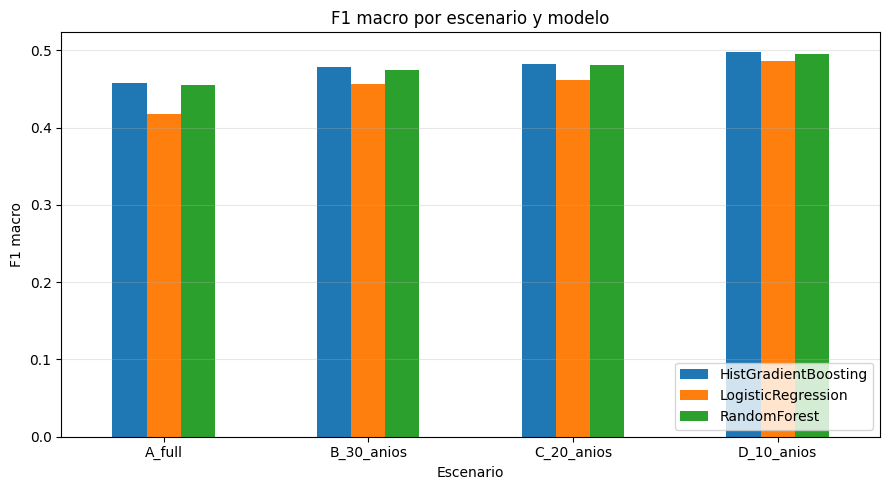

In [9]:
pivot = results_df.pivot(index='scenario', columns='model', values='f1_macro')
print(pivot.round(4))

ax = pivot.plot(kind='bar', figsize=(9,5))
plt.ylabel('F1 macro'); plt.xlabel('Escenario'); plt.title('F1 macro por escenario y modelo')
plt.xticks(rotation=0); plt.grid(axis='y', alpha=.3); plt.legend(loc='lower right')
plt.tight_layout(); plt.show()


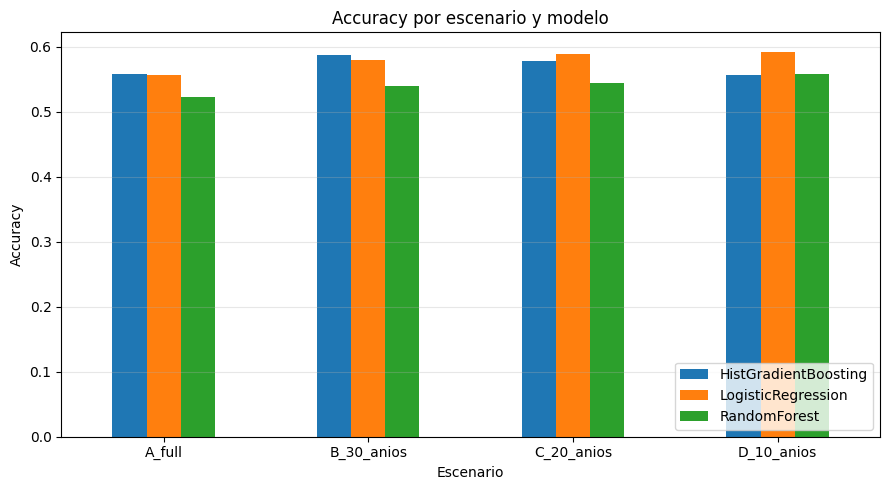

In [10]:
pivot_acc = results_df.pivot(index='scenario', columns='model', values='accuracy')
ax = pivot_acc.plot(kind='bar', figsize=(9,5))
plt.ylabel('Accuracy'); plt.xlabel('Escenario'); plt.title('Accuracy por escenario y modelo')
plt.xticks(rotation=0); plt.grid(axis='y', alpha=.3); plt.legend(loc='lower right')
plt.tight_layout(); plt.show()


## 8. Matrices de confusión para el mejor modelo de cada escenario

     scenario               label                 model  accuracy  f1_macro  auc_macro
0  D_10_anios     Últimos 10 años  HistGradientBoosting    0.5567    0.4986     0.7100
1  C_20_anios     Últimos 20 años  HistGradientBoosting    0.5784    0.4823     0.7155
2  B_30_anios     Últimos 30 años  HistGradientBoosting    0.5866    0.4788     0.7176
3      A_full  Histórico completo  HistGradientBoosting    0.5585    0.4575     0.6889


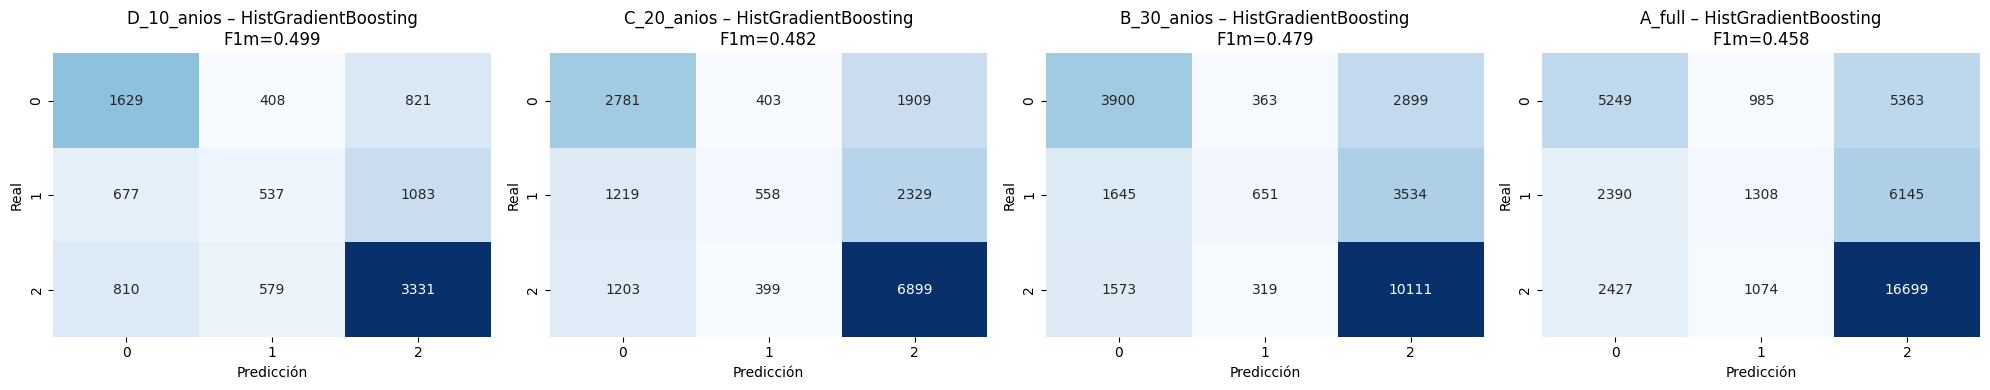

In [11]:
best_per_scenario = (results_df.sort_values('f1_macro', ascending=False)
                                .groupby('scenario').head(1)
                                .reset_index(drop=True))
print(best_per_scenario[['scenario','label','model','accuracy','f1_macro','auc_macro']].round(4))

fig, axes = plt.subplots(1, 4, figsize=(20,4))
for i, row in best_per_scenario.iterrows():
    sc, mod = row['scenario'], row['model']
    yt = detailed[(sc,mod)]['y_test']; yp = detailed[(sc,mod)]['y_pred']
    cm = confusion_matrix(yt, yp)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i], cbar=False)
    axes[i].set_title(f'{sc} – {mod}\nF1m={row["f1_macro"]:.3f}')
    axes[i].set_xlabel('Predicción'); axes[i].set_ylabel('Real')
plt.tight_layout(); plt.show()


## 9. Importancia de variables (Random Forest) por escenario

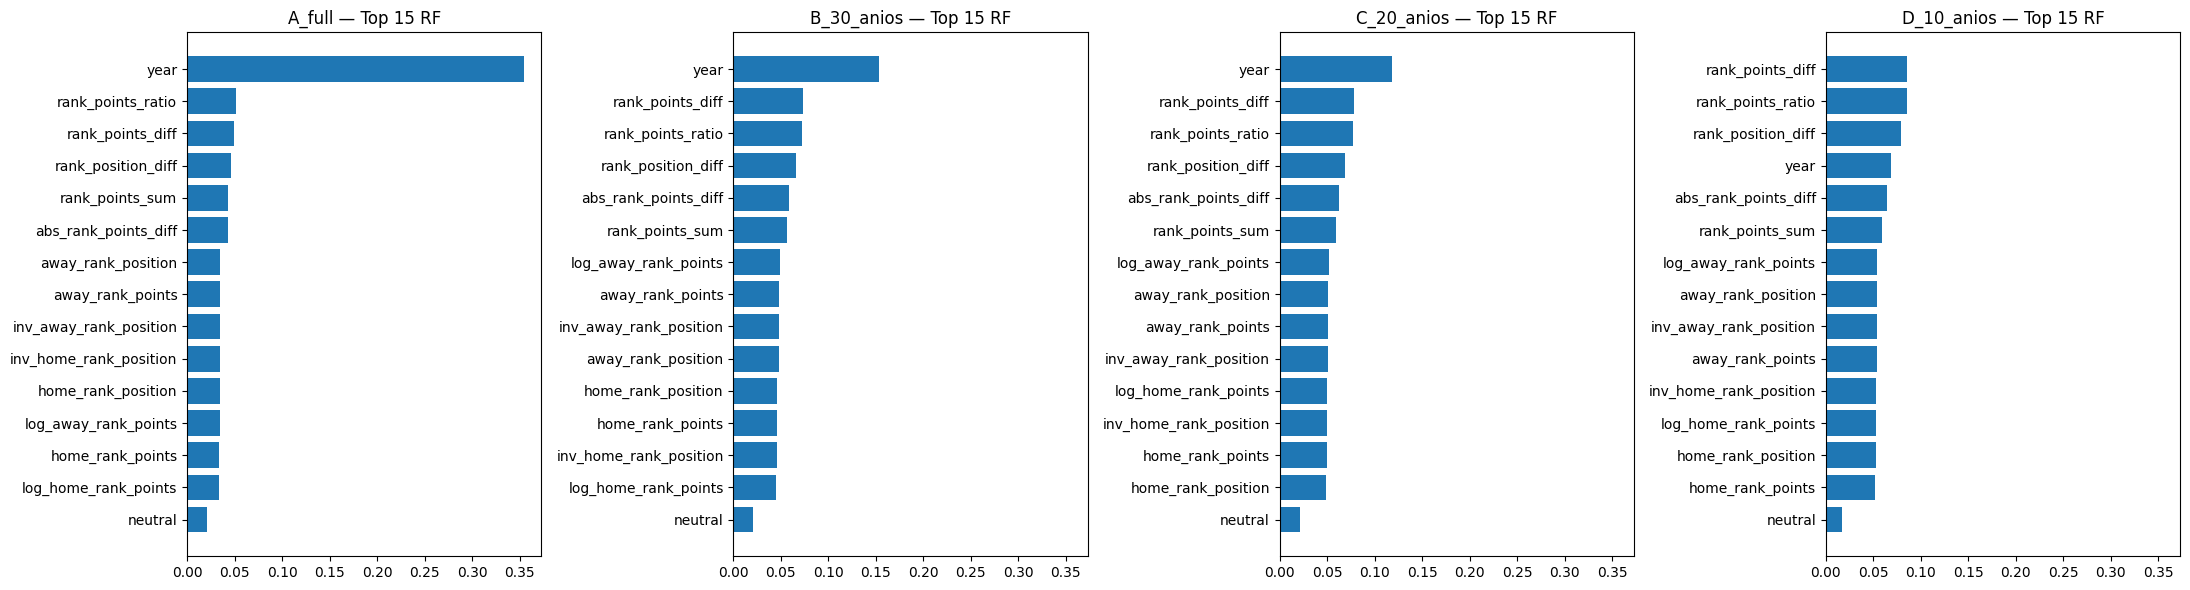

In [12]:
fig, axes = plt.subplots(1, 4, figsize=(22, 6), sharex=True)
for i, sc in enumerate(scenarios):
    imp = detailed[(sc,'RandomForest')]['metrics'].get('feature_importance_mean')
    if imp is None: continue
    df_imp = pd.DataFrame({'feature': features, 'importance': imp})\
              .sort_values('importance', ascending=True).tail(15)
    axes[i].barh(df_imp['feature'], df_imp['importance'])
    axes[i].set_title(f'{sc} — Top 15 RF')
plt.tight_layout(); plt.show()


## 10. Validación de hipótesis (resumen automático)

In [13]:
# H1: monotonía descendente del F1 macro al alargar el horizonte (10 -> 20 -> 30 -> full)
order = ['D_10_anios','C_20_anios','B_30_anios','A_full']

print('--- Hipótesis H1 (impacto del horizonte temporal) ---')
for mod in get_models().keys():
    f1s = [results_df[(results_df.scenario==sc)&(results_df.model==mod)]['f1_macro'].iloc[0] for sc in order]
    print(f'  {mod}: ' + ' -> '.join(f'{sc}:{v:.3f}' for sc,v in zip(order,f1s)))
print()

print('--- Hipótesis H2 (trade-off, óptimo en 20 años) ---')
for mod in get_models().keys():
    sub = results_df[results_df.model==mod].set_index('scenario')['f1_macro']
    best = sub.idxmax()
    print(f'  {mod}: mejor escenario = {best} (F1m={sub.max():.3f})')
print()

print('--- Hipótesis H4 (ensembles > LR en cada escenario) ---')
for sc in scenarios:
    lr = results_df[(results_df.scenario==sc)&(results_df.model=='LogisticRegression')]['f1_macro'].iloc[0]
    rf = results_df[(results_df.scenario==sc)&(results_df.model=='RandomForest')]['f1_macro'].iloc[0]
    hgb= results_df[(results_df.scenario==sc)&(results_df.model=='HistGradientBoosting')]['f1_macro'].iloc[0]
    print(f'  {sc}: LR={lr:.3f} | RF={rf:.3f} (Δ={rf-lr:+.3f}) | HGB={hgb:.3f} (Δ={hgb-lr:+.3f})')


--- Hipótesis H1 (impacto del horizonte temporal) ---
  LogisticRegression: D_10_anios:0.487 -> C_20_anios:0.462 -> B_30_anios:0.456 -> A_full:0.417
  RandomForest: D_10_anios:0.495 -> C_20_anios:0.481 -> B_30_anios:0.475 -> A_full:0.455
  HistGradientBoosting: D_10_anios:0.499 -> C_20_anios:0.482 -> B_30_anios:0.479 -> A_full:0.458

--- Hipótesis H2 (trade-off, óptimo en 20 años) ---
  LogisticRegression: mejor escenario = D_10_anios (F1m=0.487)
  RandomForest: mejor escenario = D_10_anios (F1m=0.495)
  HistGradientBoosting: mejor escenario = D_10_anios (F1m=0.499)

--- Hipótesis H4 (ensembles > LR en cada escenario) ---
  A_full: LR=0.417 | RF=0.455 (Δ=+0.038) | HGB=0.458 (Δ=+0.040)
  B_30_anios: LR=0.456 | RF=0.475 (Δ=+0.018) | HGB=0.479 (Δ=+0.023)
  C_20_anios: LR=0.462 | RF=0.481 (Δ=+0.018) | HGB=0.482 (Δ=+0.020)
  D_10_anios: LR=0.487 | RF=0.495 (Δ=+0.008) | HGB=0.499 (Δ=+0.012)


## 11. (H3) Robustez de las variables derivadas: top en los 4 escenarios

In [14]:
DERIVED = ['ranking_diff', 'rank_points_diff', 'rank_position_diff',
           'rank_points_ratio', 'abs_rank_points_diff', 'is_close_match']
print('Variable             ' + ' | '.join(scenarios.keys()))
for v in DERIVED:
    if v not in features:
        continue
    idx = features.index(v)
    vals = []
    for sc in scenarios:
        imp = detailed[(sc,'RandomForest')]['metrics'].get('feature_importance_mean')
        rank = (-imp).argsort().tolist().index(idx) + 1 if imp is not None else None
        vals.append(f'{rank:>3d}' if rank is not None else ' - ')
    print(f'{v:20s} ' + ' | '.join(vals))


Variable             A_full | B_30_anios | C_20_anios | D_10_anios
rank_points_diff       3 |   2 |   2 |   1
rank_position_diff     4 |   4 |   4 |   3
rank_points_ratio      2 |   3 |   3 |   2
abs_rank_points_diff   6 |   5 |   5 |   5
is_close_match        26 |  22 |  21 |  22


## 12. Experimento extra: split aleatorio vs. split temporal

Esta sección responde directamente al comentario del tutor sobre la justificación de la división temporal frente a la aleatoria. Se compara el mismo modelo (Random Forest) bajo:

- **A:** `train_test_split` estratificado aleatorio (test_size=0.2)
- **B:** TimeSeriesSplit (n_splits=5) sobre el dataset histórico completo


In [15]:
label, sub = get_scenario_df('A_full')
X = sub[features].values
y = sub[target].values

# A) Split aleatorio
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, stratify=y, random_state=SEED)
rf = RandomForestClassifier(n_estimators=200, random_state=SEED, n_jobs=-1)
rf.fit(X_tr, y_tr); y_pred_rand = rf.predict(X_te); y_proba_rand = rf.predict_proba(X_te)
y_bin_rand = label_binarize(y_te, classes=np.unique(y_te))
print('A) Split aleatorio (estratificado)')
print(f'  Accuracy:  {accuracy_score(y_te, y_pred_rand):.4f}')
print(f'  F1 macro:  {f1_score(y_te, y_pred_rand, average="macro"):.4f}')
print(f'  AUC macro: {roc_auc_score(y_bin_rand, y_proba_rand, average="macro", multi_class="ovr"):.4f}')

# B) TimeSeriesSplit
m_tscv, _, _, _ = evaluate_model_tscv(
    RandomForestClassifier(n_estimators=200, random_state=SEED, n_jobs=-1), X, y, scale=False
)
print('\nB) TimeSeriesSplit (walk-forward, 5 folds)')
print(f'  Accuracy:  {m_tscv["accuracy"]:.4f}')
print(f'  F1 macro:  {m_tscv["f1_macro"]:.4f}')
print(f'  AUC macro: {m_tscv["auc_macro"]:.4f}')


A) Split aleatorio (estratificado)
  Accuracy:  0.5214
  F1 macro:  0.4670
  AUC macro: 0.6697

B) TimeSeriesSplit (walk-forward, 5 folds)
  Accuracy:  0.5220
  F1 macro:  0.4555
  AUC macro: 0.6571


## 13. Exportación de resultados a CSV

Útil para incrustar las tablas exactas en el TFM (capítulo 12).


In [16]:
results_df.to_csv('tfm_resultados_comparativos.csv', index=False)
best_per_scenario.to_csv('tfm_mejor_modelo_por_escenario.csv', index=False)
print('Exportado: tfm_resultados_comparativos.csv')
print('Exportado: tfm_mejor_modelo_por_escenario.csv')


Exportado: tfm_resultados_comparativos.csv
Exportado: tfm_mejor_modelo_por_escenario.csv
